## Homework

1. Train NN model with custom linear architecture on A-Z Handwritten Alphabet dataset from Kaggle (image data with resolution not higher than 80x80 pixels - A-Z Handwritten Alphabet, etc.)
2. Visualize epoch progress (loss and accuracy curves) *both train and test
3. Visualize 10 random elements from test set and model results for those elements

Download dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image 
import math 

from sklearn.model_selection import train_test_split
import torch 
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader 
from torch.utils.data import Dataset
from torch import nn 
from tqdm import tqdm

define the constants

In [80]:
# for split data
train_ratio = 0.80
validation_ratio = 0.10
test_ratio = 0.10

# for train 
epochs=10
BS=32
learning_rate = 0.005

# gets device
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

#### Create the Custom Dataset Class

In [81]:
class CustomDataset(Dataset):
  def __init__(self, X, y, BatchSize, transform):
    super().__init__()
    self.BatchSize = BatchSize
    self.y = y
    self.X = X
    self.transform = transform
    
  def num_of_batches(self):
    return math.floor(len(self.list_IDs) / self.BatchSize)

  def __getitem__(self,idx):
    class_id = self.y[idx]
    img = self.X[idx].reshape(28,28)
    img = Image.fromarray(np.uint8(img * 255)).convert('L')
    img = self.transform(img)

    return img, torch.tensor(int(class_id))

  def __len__(self):
    return len(self.X)

In [82]:
fp = 'dataset/A_Z Handwritten Data.csv'
df=pd.read_csv(fp)

df = df.sample(frac=1)

X = df.iloc[:,1:].values / 255 
y = df.iloc[:,0].values

print(f"Value shape: {X.shape}")
print(f"label shape: {y.shape}")

Value shape: (372450, 784)
label shape: (372450,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_13436\1530081335.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


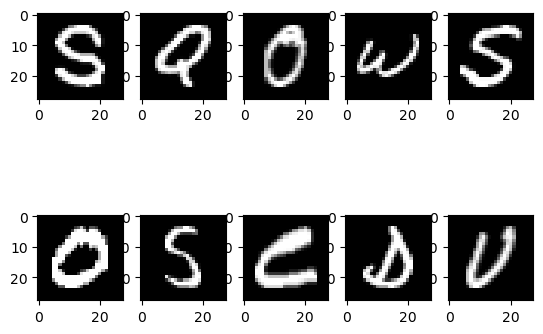

In [83]:
fig,ax = plt.subplots(2,5)
for i in range(10):
    nparray = X[i].reshape(28,28)
    image = Image.fromarray(nparray * 255)
    ax[i%2][i//2].imshow(image)
fig.show()


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio, stratify = y, random_state = 0)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio), random_state = 0)


#### Instantiate the dataloaders

In [85]:
transform = transforms.Compose([ 
                transforms.ToTensor(), 
                transforms.Normalize([0.5], [0.5])
            ])
 

dataset_stages = ['train', 'val', 'test']
 
image_datasets = {'train' : CustomDataset(X_train, y_train, BS, transform), 
                  'val' : CustomDataset(X_val, y_val, BS, transform), 
                  'test' : CustomDataset(X_test, y_test, BS, transform)}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=image_datasets[x].BatchSize,
                             shuffle=True, num_workers=0) for x in dataset_stages}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}


In [86]:
train_features, train_labels = next(iter(dataloaders['train']))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


## 1. Train NN model with custom linear architecture

### Create custom linear architecture

In [135]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 26), 
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=26, bias=True)
  )
)


In [88]:
# Initialize the loss function; also called `criterion`
loss_fn = nn.CrossEntropyLoss()

# Initialize optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

### Train NN model

In [89]:
 
# for save metricks training loop 
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        
for epoch in range(epochs):
    # for train model
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    tqdm_loader = tqdm(dataloaders['train'], unit="batch", desc=f"Epoch {epoch+1}/{epochs}")
    for batch, (X, y) in enumerate(tqdm_loader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y) 

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad() 

        running_loss += loss.item() * X.size(0)
        _, predicted = torch.max(pred, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()

        tqdm_loader.set_postfix({'loss': f'{loss.item():.4f}'})
    epoch_train_loss = running_loss / len(dataloaders['train'].dataset)
    epoch_train_acc = 100 * correct_train / total_train
        
    # for validation model 
    model.eval() 
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for X, y in dataloaders['val']:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)

            val_running_loss += loss.item() * X.size(0)
            _, predicted = torch.max(pred, 1)
            total_val += y.size(0)
            correct_val += (predicted == y).sum().item()

    epoch_val_loss = val_running_loss / len(dataloaders['val'].dataset)
    epoch_val_acc = 100 * correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")
    print("-" * 50)
        

Epoch 1/10: 100%|██████████| 9312/9312 [02:12<00:00, 70.03batch/s, loss=0.3684] 



Epoch 1/10
Train Loss: 0.8117 | Train Acc: 77.79%
Val Loss: 0.4780 | Val Acc: 86.91%
--------------------------------------------------


Epoch 2/10: 100%|██████████| 9312/9312 [02:14<00:00, 69.04batch/s, loss=0.1408]



Epoch 2/10
Train Loss: 0.3816 | Train Acc: 89.67%
Val Loss: 0.3194 | Val Acc: 91.16%
--------------------------------------------------


Epoch 3/10: 100%|██████████| 9312/9312 [02:15<00:00, 68.81batch/s, loss=0.5896]


...


Epoch 8/10
Train Loss: 0.1177 | Train Acc: 96.81%
Val Loss: 0.1348 | Val Acc: 96.26%
--------------------------------------------------


Epoch 9/10: 100%|██████████| 9312/9312 [02:11<00:00, 70.77batch/s, loss=0.0041]



Epoch 9/10
Train Loss: 0.1071 | Train Acc: 97.11%
Val Loss: 0.1146 | Val Acc: 96.86%
--------------------------------------------------


Epoch 10/10: 100%|██████████| 9312/9312 [01:59<00:00, 78.14batch/s, loss=0.0177] 



Epoch 10/10
Train Loss: 0.0983 | Train Acc: 97.37%
Val Loss: 0.1108 | Val Acc: 97.05%
--------------------------------------------------


## 2. Visualize epoch progress (loss and accuracy curves)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13436\542096061.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\Admin\AppData\Local\Temp\ipykernel_13436\542096061.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


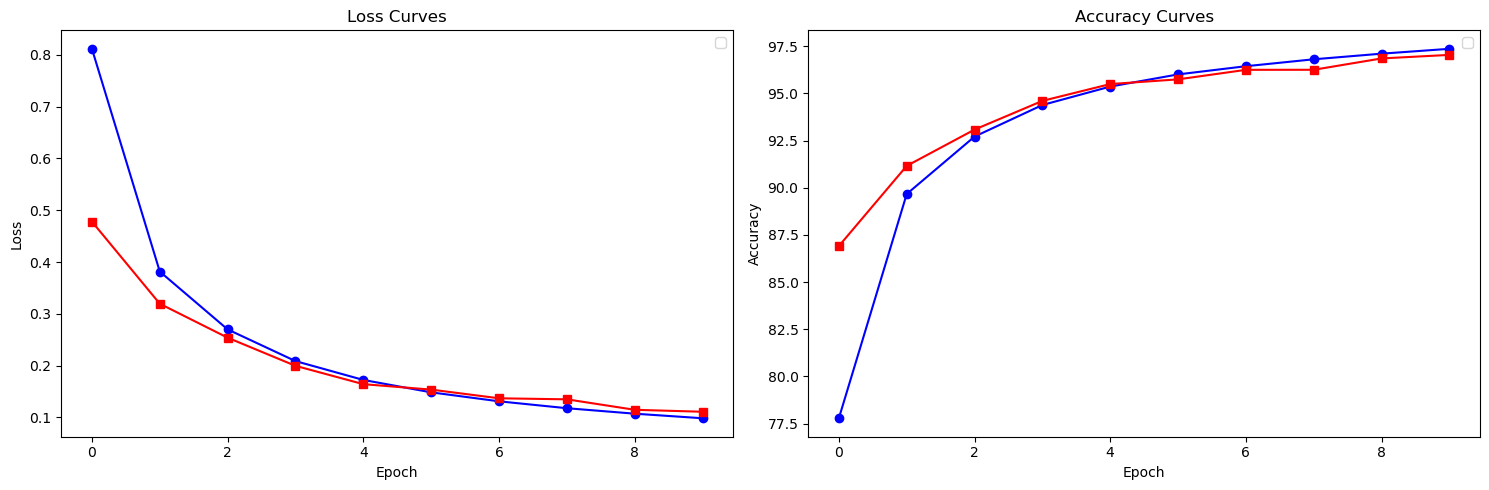

In [90]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
     
    ax1.plot(history['train_loss'], color='blue', marker='o')
    ax1.plot(history['val_loss'], color='red', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curves')
    ax1.legend() 
     
    ax2.plot(history['train_acc'], color='blue', marker='o')
    ax2.plot(history['val_acc'], color='red', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy Curves')
    ax2.legend() 
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

### Saved model

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


### Load saved model

In [137]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

## 3. Visualize 10 random elements from test set and model results for those elements

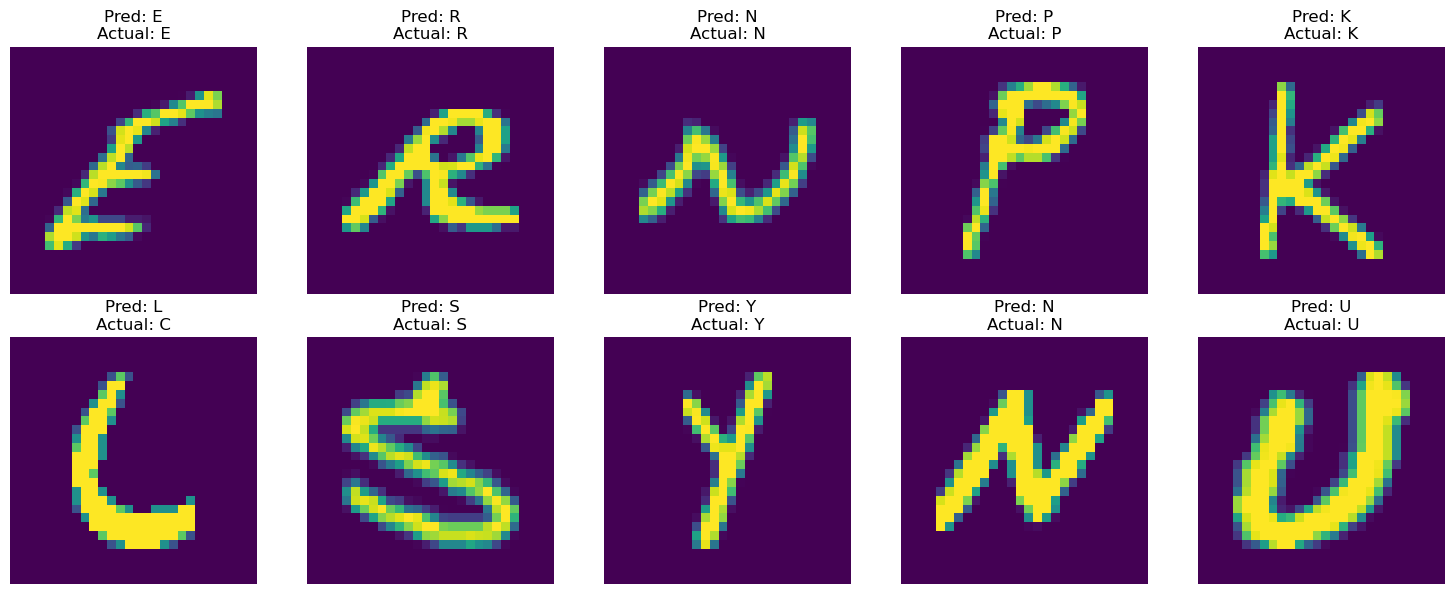

In [142]:
model.eval()
 
images, labels = next(iter(dataloaders['test']))
 
images, labels = images.to(device), labels.to(device)
 
mapper = {i: chr(65 + i) for i in range(26)}
 
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
 
axes_flat = axes.flatten()
 
batch_size = images.size(0)
random_indices = random.sample(range(batch_size), min(10, batch_size))

for idx, img_idx in enumerate(random_indices):
    img = images[img_idx]
    label = labels[img_idx]
     
    with torch.no_grad():
        output = model(img.unsqueeze(0))      
        _, predicted = torch.max(output, 1)
        pred_class = predicted.item()
     
    img_show = img.cpu().permute(1, 2, 0)     
     
    img_show = img_show * 0.5 + 0.5
    img_show = torch.clamp(img_show, 0, 1)    
     
    axes_flat[idx].set_title(f"Pred: {mapper[pred_class]}\nActual: {mapper[label.item()]}")
     
    axes_flat[idx].imshow(img_show.numpy())
    axes_flat[idx].axis('off')
plt.tight_layout()
plt.show()